# Part B - Automatic Correction (OCR)

Dans cette partie, l’objectif est de construire un système de reconnaissance automatique de caractères manuscrits à partir du dataset fourni par le professeur.

## Imports


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
sns.set_theme(style="whitegrid")

## OCR Dataset Loading

### Imports + classe MyDataset

In [3]:
import struct
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

class MyDataset(Dataset):
    def __init__(self, images_path, labels_path, mapping_path="image_data/mapping.txt"):
        # Load images
        with open(images_path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, rows, cols)

        # Load labels
        with open(labels_path, "rb") as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)

        # Load mapping from label index -> ASCII code -> character
        self.mapping = {}
        try:
            with open(mapping_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    idx_str, ascii_str = line.split(" ")
                    idx = int(idx_str)
                    ascii_val = int(ascii_str)
                    self.mapping[idx] = chr(ascii_val)
        except FileNotFoundError:
            raise FileNotFoundError(f"Mapping file not found: {mapping_path}")

        # Fix orientation (rotated)
        images = np.transpose(images, (0, 2, 1)).copy()

        # Convert to PyTorch tensors
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        # Convert to character labels from mapping
        if not self.mapping:
            raise ValueError("Empty mapping, cannot map label indices to characters")
        self.char_labels = [self.mapping[int(l)] for l in labels]
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0), self.char_labels[idx]

    def show_sample(self, idx=0, count=1):
        if count == 1:
            img, lbl = self[idx]
            img_np = img.squeeze(0).numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(img_np, cmap='gray')
            plt.title(f"Label: {lbl}")
            plt.axis('off')
            plt.show()
            return

        count = min(count, len(self)-idx)
        cols = min(5, count)
        rows = (count + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        axes = np.array(axes).reshape(-1)

        for i in range(count):
            img, lbl = self[idx + i]
            img_np = img.squeeze(0).numpy()
            ax = axes[i]
            ax.imshow(img_np, cmap='gray')
            ax.set_title(f"{idx+i}:{lbl}", fontsize=10)
            ax.axis('off')

        for i in range(count, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()



### Charnement dataset

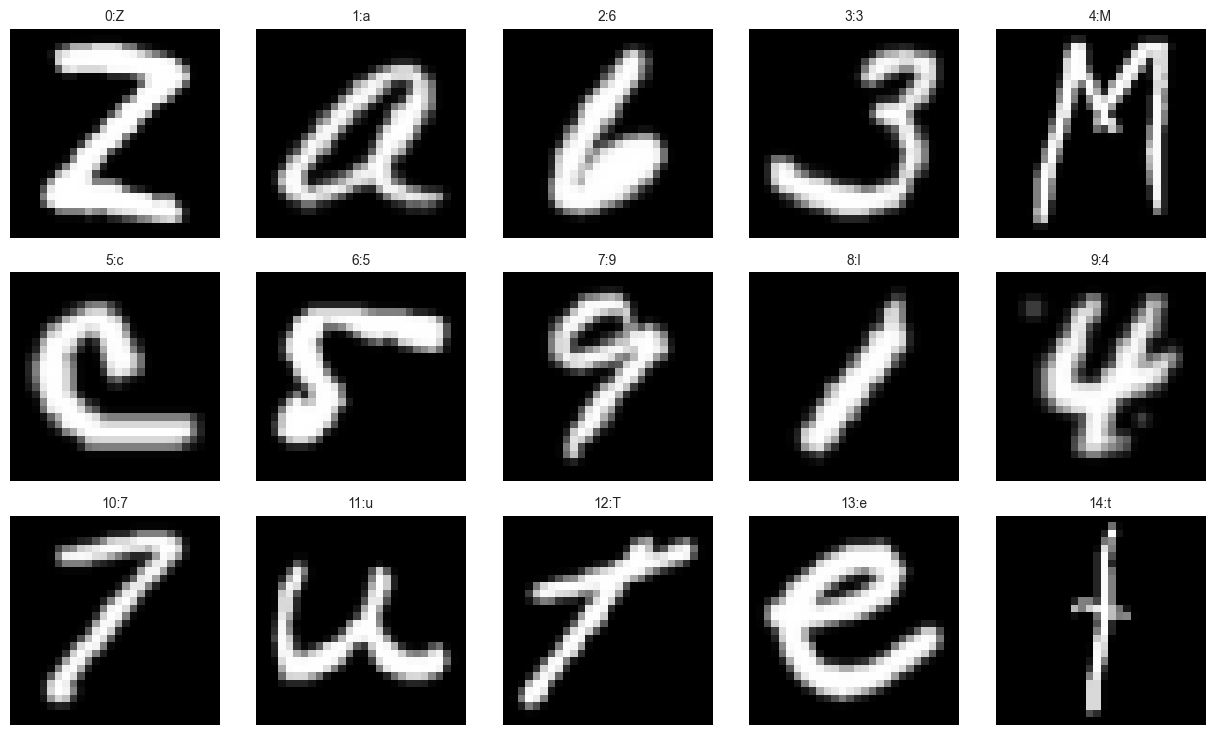

<Figure size 640x480 with 0 Axes>

In [18]:
images_file = "../data/image_data/train-images-idx3-ubyte"
labels_file = "../data/image_data/train-labels-idx1-ubyte"
mapping_file = "../data/image_data/mapping.txt"

dataset = MyDataset(images_file, labels_file, mapping_file)

# affichage d'exemples d'images OCR
dataset.show_sample(idx=0, count=15)

# sauvegarde de la figure pour le rapport
plt.savefig(
    "ocr_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis



Le dataset OCR fourni contient des images de caractères manuscrits, incluant à la fois des chiffres et des lettres.

Chaque image est représentée sous la forme d’une matrice de pixels en niveaux de gris de taille 28×28. Les labels numériques associés sont convertis en caractères grâce à un fichier de mapping permettant d’obtenir les correspondances ASCII.

Les exemples affichés montrent une forte variabilité dans l’écriture des caractères manuscrits :
- différences de forme,
- inclinaison,
- épaisseur des traits,
- qualité d’écriture.

Certaines classes présentent également des similitudes visuelles importantes, comme certains chiffres et lettres proches, ce qui rend la tâche de reconnaissance plus complexe.

Ce dataset constitue donc une base réaliste et pertinente pour l’entraînement et l’évaluation de modèles de reconnaissance automatique de caractères (OCR).

## OCR Data Preprocessing

### flatten images

In [5]:
from pathlib import Path
import numpy as np

N = len(dataset)
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

X_mm = np.memmap(data_dir / "ocr_X.dat", dtype=np.uint8, mode="w+", shape=(N, 784))
y_mm = np.memmap(data_dir / "ocr_y.dat", dtype=np.uint16, mode="w+", shape=(N,))

for i, (img, lbl) in enumerate(dataset):
    X_mm[i] = (img.numpy().squeeze() * 255).astype(np.uint8).ravel()
    y_mm[i] = ord(lbl)

X_mm.flush()
y_mm.flush()

# ensuite utiliser X_mm (mappé) pour échantillonnage/training par batches

#### Analysis

Après le preprocessing, le dataset OCR contient 697 932 images.

Chaque image de taille 28 × 28 pixels a été transformée en un vecteur de 784 valeurs numériques.

La variable `y` contient le caractère associé à chaque image. Il s’agit donc d’un problème de classification multiclasse, car le modèle doit prédire une classe parmi plusieurs caractères possibles.

### Train/test split avec stratify

In [6]:
indices = np.arange(N)

labels = np.array(dataset.char_labels)
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=labels
)

X_train_idx, X_test_idx = train_idx, test_idx
y_train, y_test = labels[train_idx], labels[test_idx]

X_train_idx.shape, X_test_idx.shape

((558345,), (139587,))

### Analysis

Le dataset OCR a été divisé en deux ensembles :

- Un ensemble d’entraînement contenant 558 345 images.
- Un ensemble de test contenant 139 587 images.

L’ensemble d’entraînement sera utilisé pour apprendre au modèle à reconnaître les caractères manuscrits, tandis que l’ensemble de test permettra d’évaluer ses performances sur des images non vues.

Le paramètre `stratify=y` est utilisé afin de conserver une répartition équilibrée des différentes classes dans les deux ensembles. Cela est important dans un problème de classification multiclasse, car certaines classes peuvent être plus fréquentes que d’autres.

## Random Forest OCR Model

### Sous-échantillon

In [19]:
import numpy as np

# sous-échantillonnage pour accélérer l'entraînement
subset_size = 100000

np.random.seed(42)
subset_pos = np.random.choice(len(train_idx), subset_size, replace=False)
subset_idx = train_idx[subset_pos]

X_train_small = X_mm[subset_idx]
y_train_small = y_train[subset_pos]

X_train_small.shape, y_train_small.shape

((100000, 784), (100000,))

### Analysis

Un sous-échantillon de 100000 images a été utilisé afin d’accélérer l’entraînement du modèle Random Forest et de réduire le coût computationnel.

Le dataset OCR complet contient plusieurs centaines de milliers d’images, ce qui rend l’entraînement sur l’ensemble total particulièrement coûteux en temps et en mémoire.

Chaque image est représentée sous la forme d’un vecteur de 784 pixels correspondant à une image 28×28 aplatie.

Le sous-échantillonnage permet donc d’obtenir un compromis efficace entre temps d’entraînement et qualité des performances du modèle.

### Entraînement

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

ocr_rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# entraînement
ocr_rf_model.fit(X_train_small, y_train_small)

# prédiction
y_pred_rf = ocr_rf_model.predict(X_mm[test_idx])

# accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest OCR Accuracy:", accuracy_rf)

Random Forest OCR Accuracy: 0.786362626892189


### Analysis

Le modèle Random Forest est utilisé comme première approche de classification pour la tâche OCR.

Chaque image étant aplatie en un vecteur de 784 pixels, le modèle apprend à associer les intensités de pixels aux caractères correspondants.

Le modèle atteint une accuracy d’environ 78.6 %, ce qui montre qu’il est capable de reconnaître correctement une grande partie des caractères manuscrits.

Cependant, cette approche reste limitée car le Random Forest traite les pixels comme des variables indépendantes et ne prend pas directement en compte la structure spatiale de l’image.

### Confusioin Matrix

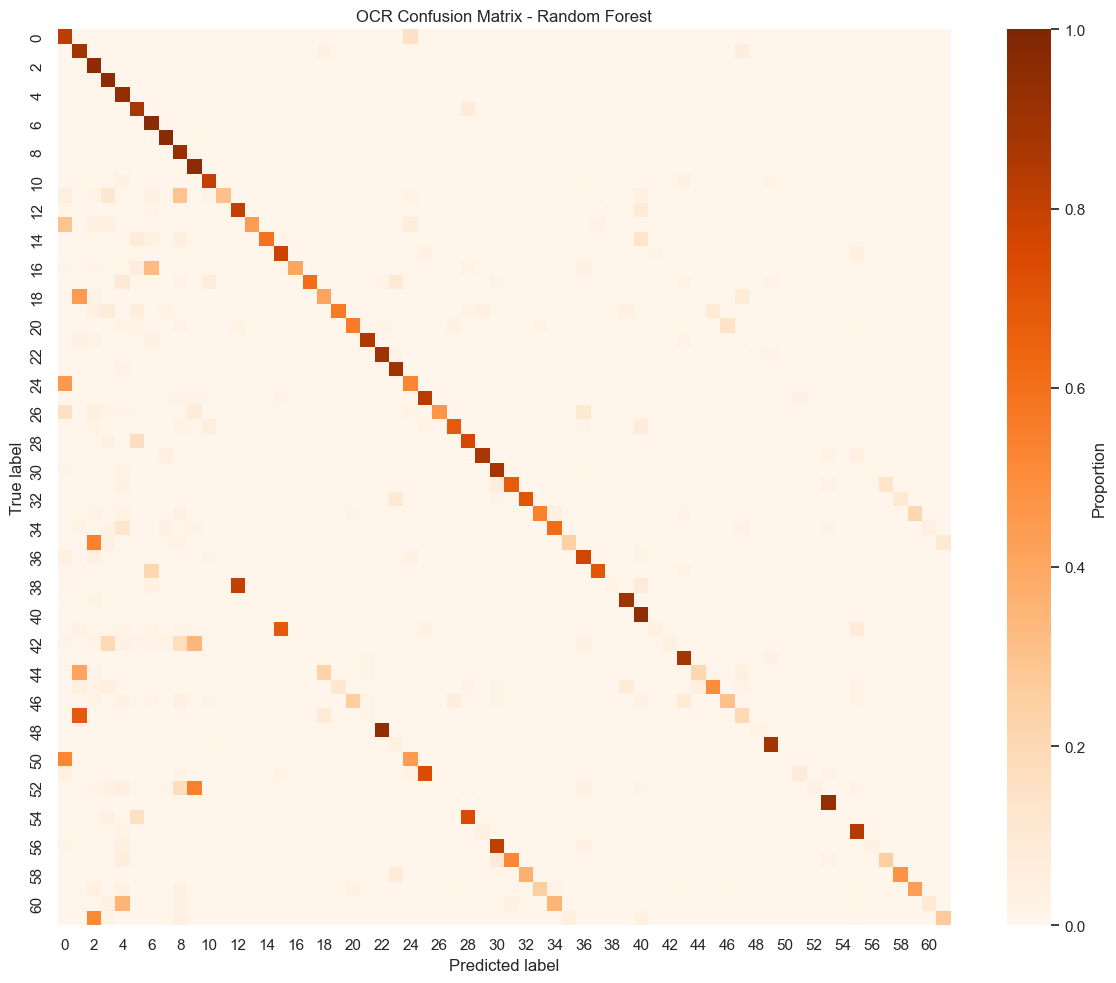

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm_rf = confusion_matrix(y_test, y_pred_rf)

# normalisation par ligne
cm_rf_norm = cm_rf.astype("float") / cm_rf.sum(axis=1, keepdims=True)
cm_rf_norm = np.nan_to_num(cm_rf_norm)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_rf_norm,
    cmap="Oranges",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion"}
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("OCR Confusion Matrix - Random Forest")

plt.tight_layout()

plt.savefig("ocr_confusion_matrix_rf.png", dpi=300, bbox_inches="tight")

plt.show()

### Analysis


La matrice de confusion normalisée montre que la majorité des prédictions se situent sur la diagonale principale, ce qui indique que le modèle reconnaît correctement une grande partie des caractères manuscrits.

Certaines erreurs restent néanmoins visibles entre des classes visuellement proches, ce qui est fréquent dans les problèmes OCR manuscrits. Les différences d’écriture, l’épaisseur des traits ou certaines formes ambiguës rendent la classification plus difficile pour certains caractères.

Ces résultats montrent que le Random Forest est capable d’apprendre des patterns pertinents à partir des pixels des images.

Cependant, les images étant aplaties sous forme de vecteurs de 784 pixels, le modèle ne prend pas directement en compte la structure spatiale des caractères.

Cette limitation explique pourquoi des modèles de deep learning peuvent être plus adaptés aux tâches de reconnaissance d’images et de caractères manuscrits.

## OCR Deep Learning Model (CNN)

### Label encoding

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)

print("Number of classes:", num_classes)

Number of classes: 62


### Analysis

Les labels des caractères sont encodés numériquement à l’aide de `LabelEncoder`.

Cette étape permet de convertir chaque caractère en une classe numérique utilisable par le modèle de deep learning.

Le nombre total de classes correspond au nombre de caractères différents à reconnaître.

### Model architecture

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,742 (905.24 KB)

 Trainable params: 231,742 (905.24 KB)

 Non-trainable params: 0 (0.00 B)

### Analysis

Le modèle utilisé est un réseau de neurones convolutionnel (CNN).

Contrairement au Random Forest, qui travaille sur des images aplaties sous forme de vecteurs, le CNN conserve la structure spatiale des images en 28×28 pixels.

Les couches `Conv2D` permettent d’extraire automatiquement des motifs visuels locaux, comme les traits, les courbes ou les contours des caractères.

Les couches `MaxPooling2D` réduisent progressivement la taille des représentations tout en conservant les informations importantes.

La couche `Dropout` est utilisée afin de limiter le risque de surapprentissage.

La couche finale `softmax` produit une probabilité pour chaque classe de caractère.

### Training

In [24]:
subset_size = 120000

np.random.seed(42)
subset_pos = np.random.choice(len(train_idx), subset_size, replace=False)
subset_idx = train_idx[subset_pos]

X_train_dl = X_mm[subset_idx].reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_train_dl = y_train_enc[subset_pos].astype("int32")

print(X_train_dl.shape)
print(y_train_dl.shape)
print(X_train_dl.dtype)
print(y_train_dl.dtype)

history = cnn_model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    verbose=1
)

(120000, 28, 28, 1)
(120000,)
float32
int32
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step - accuracy: 0.6350 - loss: 1.3411 - val_accuracy: 0.7861 - val_loss: 0.6596
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.7758 - loss: 0.6971 - val_accuracy: 0.8182 - val_loss: 0.5346
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8020 - loss: 0.5950 - val_accuracy: 0.8267 - val_loss: 0.5017
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8142 - loss: 0.5466 - val_accuracy: 0.8346 - val_loss: 0.4765
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.8234 - loss: 0.5147 - val_accuracy: 0.8397 - val_loss: 0.4620
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8286 - loss: 0.4932 - val_accuracy: 0.8397 - val_loss: 0.4572
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8328 - loss: 0.4742 - val_accuracy: 0.8452 - val_loss: 0.4460
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 70

### Analysis

Un sous-échantillon de 120000 images est utilisé afin de réduire le temps de calcul tout en conservant une grande diversité de caractères manuscrits.

Les images sont normalisées et redimensionnées au format `(28, 28, 1)` afin d’être compatibles avec les couches convolutionnelles du réseau.

Une partie des données d’entraînement est utilisée comme ensemble de validation (`validation_split=0.2`) afin de suivre l’évolution des performances du modèle pendant l’apprentissage.

Les résultats montrent une augmentation progressive de l’accuracy d’entraînement, passant d’environ 63 % à près de 87 % après 20 époques.

L’accuracy de validation atteint environ 85 %, ce qui indique une bonne capacité de généralisation du modèle sur des données non vues.

La loss diminue rapidement durant les premières époques puis se stabilise progressivement, ce qui montre une convergence correcte du réseau.

On observe également qu’à partir des dernières époques, l’accuracy d’entraînement continue d’augmenter alors que l’accuracy de validation se stabilise. Cela suggère l’apparition d’un léger phénomène de surapprentissage (overfitting), bien qu’il reste limité grâce à l’utilisation du `Dropout`.

### Accuracy/ Loss curves 

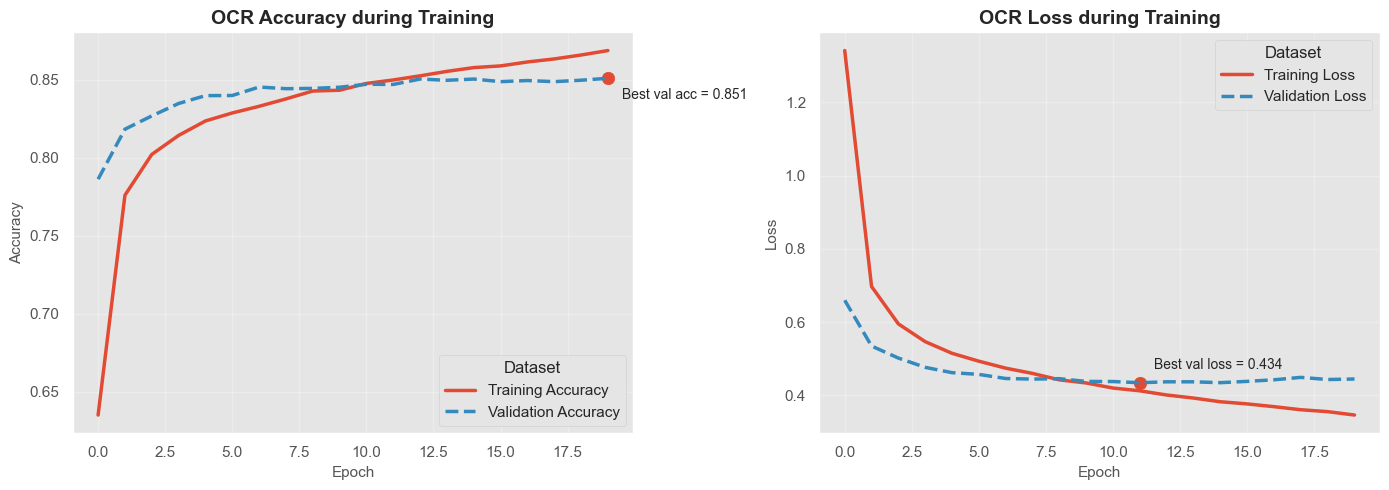

In [25]:
plt.style.use("ggplot")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(
    history.history["accuracy"],
    linewidth=2.5,
    label="Training Accuracy"
)

axes[0].plot(
    history.history["val_accuracy"],
    linewidth=2.5,
    linestyle="--",
    label="Validation Accuracy"
)

axes[0].set_title(
    "OCR Accuracy during Training",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Accuracy", fontsize=11)

axes[0].legend(title="Dataset")
axes[0].grid(True, alpha=0.3)

# annotation meilleure accuracy validation
best_acc_epoch = np.argmax(history.history["val_accuracy"])
best_acc = history.history["val_accuracy"][best_acc_epoch]

axes[0].scatter(best_acc_epoch, best_acc, s=80)

axes[0].annotate(
    f"Best val acc = {best_acc:.3f}",
    (best_acc_epoch, best_acc),
    textcoords="offset points",
    xytext=(10, -15),
    fontsize=10
)


# Loss
axes[1].plot(
    history.history["loss"],
    linewidth=2.5,
    label="Training Loss"
)

axes[1].plot(
    history.history["val_loss"],
    linewidth=2.5,
    linestyle="--",
    label="Validation Loss"
)

axes[1].set_title(
    "OCR Loss during Training",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Loss", fontsize=11)

axes[1].legend(title="Dataset")
axes[1].grid(True, alpha=0.3)

# annotation meilleure loss validation
best_loss_epoch = np.argmin(history.history["val_loss"])
best_loss = history.history["val_loss"][best_loss_epoch]

axes[1].scatter(best_loss_epoch, best_loss, s=80)

axes[1].annotate(
    f"Best val loss = {best_loss:.3f}",
    (best_loss_epoch, best_loss),
    textcoords="offset points",
    xytext=(10, 10),
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "ocr_training_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

Les courbes d’apprentissage montrent une amélioration progressive des performances du modèle au cours des époques.

L’accuracy d’entraînement augmente régulièrement jusqu’à environ 87 %, tandis que l’accuracy de validation se stabilise autour de 85 %.

La loss diminue fortement durant les premières époques puis converge progressivement vers une valeur stable, ce qui indique que le modèle apprend correctement les caractéristiques des caractères manuscrits.

On observe cependant qu’à partir des dernières époques, l’accuracy d’entraînement continue d’augmenter alors que l’accuracy de validation évolue plus lentement.

De même, la loss d’entraînement continue de diminuer alors que la loss de validation se stabilise.

Ce comportement indique l’apparition d’un léger phénomène de surapprentissage (overfitting), bien que celui-ci reste limité grâce à l’utilisation du Dropout et à la validation pendant l’apprentissage.

Globalement, le modèle présente une bonne capacité de généralisation sur les données OCR.

### Overfitting / Underfitting Analysis

Les courbes d’apprentissage montrent que l’accuracy augmente progressivement au cours des époques tandis que la loss diminue de manière régulière.

Les performances sur l’ensemble de validation restent proches de celles obtenues sur l’ensemble d’entraînement, ce qui indique une bonne capacité de généralisation du modèle.

On observe cependant qu’à partir des dernières époques, l’accuracy d’entraînement continue d’augmenter alors que l’accuracy de validation se stabilise autour de 85 %.

De même, la loss d’entraînement continue de diminuer alors que la loss de validation évolue plus lentement.

Ce comportement suggère l’apparition d’un léger phénomène de surapprentissage (overfitting), mais celui-ci reste limité grâce à l’utilisation du Dropout et du validation split durant l’apprentissage.

Le modèle ne présente pas de sous-apprentissage (underfitting), car il atteint une accuracy élevée et apprend correctement les caractéristiques des caractères manuscrits.

Globalement, le réseau présente un bon compromis entre capacité d’apprentissage et généralisation.

### Test evaluation

In [26]:
# préparation des images de test
X_test_dl = X_mm[test_idx].reshape(-1, 28, 28, 1).astype("float32") / 255.0

# prédictions du modèle
y_pred_dl_prob = model.predict(X_test_dl, batch_size=512)

# conversion probabilités -> classes
y_pred_dl = y_pred_dl_prob.argmax(axis=1)

# accuracy finale
accuracy_dl = accuracy_score(y_test_enc, y_pred_dl)

print("Deep Learning OCR Accuracy:", accuracy_dl)

273/273 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step
Deep Learning OCR Accuracy: 0.8493269430534363


### Analysis

Le modèle de deep learning obtient une accuracy d’environ 85 % sur l’ensemble de test.

Les performances sont supérieures à celles du modèle Random Forest, ce qui montre que les réseaux de neurones convolutionnels sont mieux adaptés à la reconnaissance d’images.

Contrairement au Random Forest, le CNN exploite directement la structure spatiale des pixels grâce aux couches convolutionnelles.

Le modèle est ainsi capable d’apprendre des caractéristiques visuelles plus complexes, ce qui améliore la reconnaissance des caractères manuscrits.

## OCR Model Comparaison

### Tableau RF vs MLP

In [27]:
results_ocr = pd.DataFrame({
    "Model": ["Random Forest", "Deep Learning (CNN)"],
    "Accuracy": [accuracy_rf, accuracy_dl]
})

results_ocr

,Model,Accuracy
0,Random Forest,0.786363
1,Deep Learning (CNN),0.849327


### Graphe accuracy

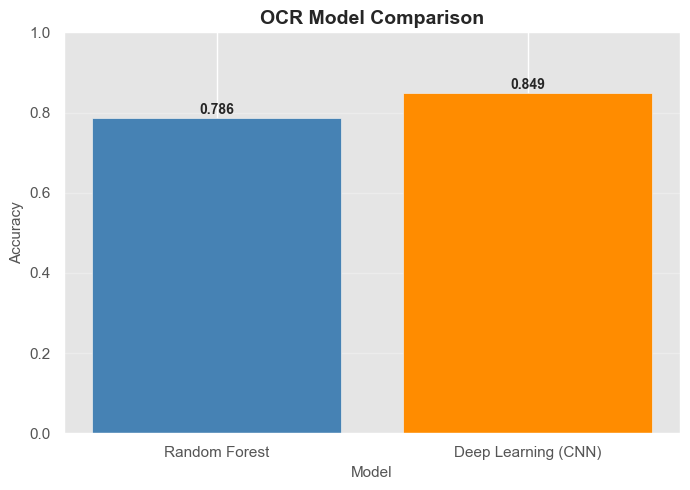

In [29]:
plt.style.use("ggplot")

plt.figure(figsize=(7,5))

bars = plt.bar(
    results_ocr["Model"],
    results_ocr["Accuracy"],
    color=["steelblue", "darkorange"]
)

plt.ylim(0, 1)

plt.title(
    "OCR Model Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)

plt.grid(axis="y", alpha=0.3)

# valeurs sur les barres
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "ocr_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

La comparaison des modèles montre que le modèle de deep learning convolutionnel (CNN) obtient de meilleures performances que le Random Forest sur la tâche OCR.

Le Random Forest atteint une accuracy d’environ 78.6 %, tandis que le modèle CNN atteint environ 84.9 % sur l’ensemble de test.

Cette différence s’explique par la capacité du réseau convolutionnel à exploiter directement la structure spatiale des images grâce aux couches de convolution et de pooling.

À l’inverse, le Random Forest travaille sur des images aplaties sous forme de vecteurs de pixels, ce qui entraîne une perte d’information spatiale importante.

Contrairement à la partie A, où les relations entre variables étaient principalement linéaires, la tâche OCR repose sur des données visuelles beaucoup plus complexes.

Ces résultats montrent que les modèles de deep learning sont particulièrement adaptés aux problèmes de reconnaissance d’images et de caractères manuscrits.

Contrairement à la partie A, où les relations entre variables étaient principalement linéaires, la partie OCR implique des données visuelles complexes.

Cela explique pourquoi les modèles de deep learning sont plus performants dans ce contexte.

## Conclusion

Dans ce projet, deux problématiques d’intelligence artificielle ont été étudiées : la prédiction des performances académiques et la reconnaissance automatique de caractères manuscrits (OCR).

Dans la première partie, plusieurs modèles de machine learning ont été comparés afin de prédire les scores d’examen des étudiants à partir de différentes variables explicatives.

Les résultats obtenus montrent que la régression linéaire et XGBoost offrent les meilleures performances, avec un coefficient de détermination proche de 0.76 et des erreurs de prédiction relativement faibles.

Les différentes analyses réalisées indiquent que les relations présentes dans le dataset sont principalement linéaires. Les modèles plus complexes, comme Random Forest ou le réseau de neurones MLP, n’apportent qu’une amélioration très limitée malgré une complexité plus importante.

Dans la seconde partie, consacrée à la reconnaissance automatique de caractères manuscrits, des approches basées sur l’analyse d’images ont été étudiées.

Le modèle Random Forest obtient une accuracy d’environ 78.6 %, ce qui constitue une baseline correcte pour la tâche OCR. Cependant, ce modèle reste limité car il traite les images comme de simples vecteurs de pixels sans exploiter leur structure spatiale.

Le modèle de deep learning convolutionnel (CNN) obtient de meilleures performances, avec une accuracy proche de 84.9 % sur l’ensemble de test.

Les courbes d’apprentissage montrent une diminution progressive de la loss ainsi qu’une augmentation stable de l’accuracy, indiquant une bonne capacité de généralisation malgré un léger phénomène de surapprentissage en fin d’entraînement.

Ce projet met ainsi en évidence l’importance du choix du modèle en fonction de la nature des données.

Les données tabulaires peuvent être correctement modélisées par des approches simples et interprétables, tandis que les données visuelles nécessitent des architectures plus avancées capables d’extraire des caractéristiques spatiales complexes.

Enfin, plusieurs pistes d’amélioration restent possibles, notamment l’utilisation de CNN plus profonds, l’augmentation artificielle des données (\textit{data augmentation}) ainsi que l’optimisation des hyperparamètres afin d’améliorer davantage les performances du système OCR.